In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import null_space
import cvxpy as cp
from scipy.optimize import linprog
import copy
from physiology_utilities import computeFlows, dictToVec, vecToDict, dictToGraph, graphToDict

Text(0.5, 0, 'Time (h)')

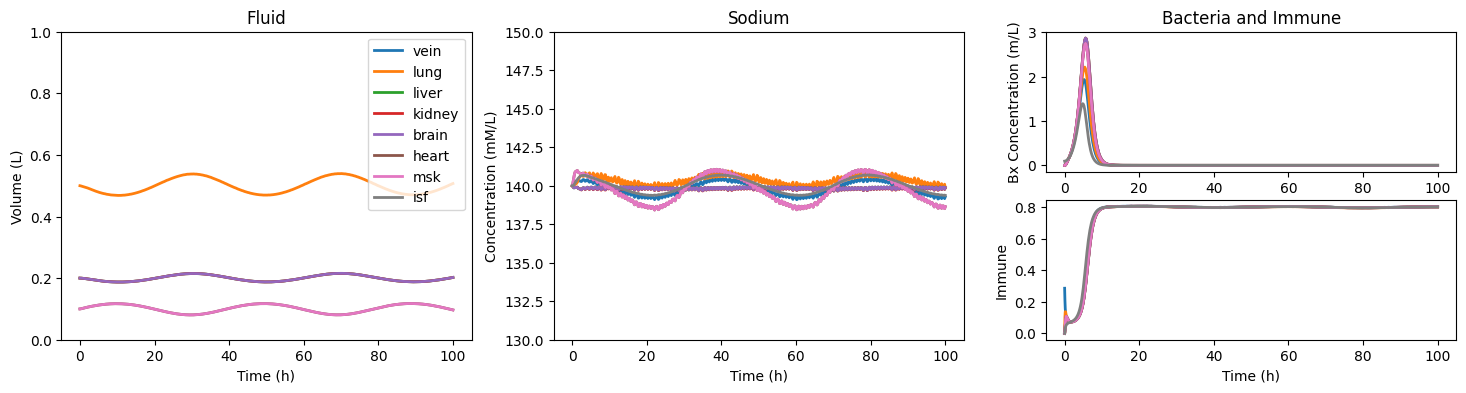

In [12]:
speciesList = ['vol','na','bx','im','albumin','ox']
compartmentList = ['vein','lung','liver','kidney','brain','heart','msk','isf']
### Functions
def getTGoal(t):
    return (np.sin(t/(2*np.pi)))*0.25+1

# by-species module of dynamics (takes species in, returns time derivatives)
def flowDynamics(t,species,inflow,growth,klocal):
    dspecies = {}
    k = copy.deepcopy(klocal)
    k['lung']['msk'] *= getTGoal(t)
    k['lung']['heart'] *= getTGoal(t)
    
    backToVeins = k['liver']['vein']*species['liver']+k['kidney']['vein']*species['kidney']+k['brain']['vein']*species['brain']+k['heart']['vein']*species['heart']+k['msk']['vein']*species['msk']
    outFromRightHeart = (k['lung']['liver']+k['lung']['kidney']+k['lung']['brain']+k['lung']['heart']+k['lung']['msk'])*species['lung']
    dspecies['vein'] = growth['vein']*species['vein'] + k['isf']['vein']*species['isf'] + backToVeins - k['vein']['isf']*species['vein'] - k['vein']['lung']*species['vein'] + inflow['vein']
    dspecies['lung'] = growth['lung']*species['lung'] + k['vein']['lung']*species['vein']-outFromRightHeart+inflow['lung']
    dspecies['liver'] = growth['liver']*species['liver'] + k['lung']['liver']*species['lung']-k['liver']['vein']*species['liver']+inflow['liver']
    dspecies['kidney'] = growth['kidney']*species['kidney'] + k['lung']['kidney']*species['lung']-k['kidney']['vein']*species['kidney']+inflow['kidney']
    dspecies['brain'] = growth['brain']*species['brain']  + k['lung']['brain']*species['lung']-k['brain']['vein']*species['brain'] + inflow['brain']
    dspecies['heart'] = growth['heart']*species['heart'] + k['lung']['heart']*species['lung']-k['heart']['vein']*species['heart'] + inflow['heart']
    dspecies['msk'] = growth['msk']*species['msk']+k['lung']['msk']*species['lung']-k['msk']['vein']*species['msk'] + inflow['msk']
    dspecies['isf'] = growth['isf']*species['isf'] + k['vein']['isf']*species['vein']-k['isf']['vein']*species['isf']+inflow['isf']
    return dspecies

# core ODE function; takes in (t), (x), and returns (xdot)
def odemasterfxn(t, state,klocal):
    # Unpack the state variables using vecToDict
    stateDict = vecToDict(state,speciesList,compartmentList)
    # binding: sodium travels with fluid
    stateDict['massna'] = {}
    for key in stateDict['na'].keys():
        stateDict['massna'][key] = stateDict['na'][key]*stateDict['vol'][key]
    # initialize inflow and growth
    inflow = vecToDict(0,speciesList,compartmentList)
    growth = vecToDict(0,speciesList,compartmentList)
    volsum = 0
    for key in stateDict['vol'].keys():
        volsum+=stateDict['vol'][key]
    
    # binding: implement the concentration-driven relationship between fluids and sodium inflow and output
    # NOTE: these rate constants are unknowns
    k_uop = .2
    k_inflow = 2.75
    inflow['vol']['vein'] = k_inflow*(ssNa-(stateDict['na']['brain']))/ssNa*(volsum)
    inflow['na']['vein']  = inflow['vol']['vein']*ssNa
    inflow['na']['kidney'] = -k_uop*(stateDict['na']['kidney']-ssNa)
    inflow['vol']['kidney'] = inflow['na']['kidney']/ssNa*stateDict['vol']['kidney']

    for key in growth['bx'].keys():
        growth['bx'][key] = a-imKillRate*stateDict['im'][key]
    for key in growth['im'].keys():
        growth['im'][key] = aIm*stateDict['bx'][key]

    diffDict = vecToDict(0,speciesList,compartmentList)
    # dynamics: call the modular flowDynamics function for each species
    diffDict['vol'] = flowDynamics(t,stateDict['vol'],inflow['vol'],growth['vol'],klocal)
    diffDict['na'] = flowDynamics(t,stateDict['massna'],inflow['na'],growth['na'],klocal)
    for key in diffDict['na'].keys():
        diffDict['na'][key] = diffDict['na'][key]/stateDict['vol'][key]
    diffDict['bx'] = flowDynamics(t,stateDict['bx'],inflow['bx'],growth['bx'],klocal) 
    diffDict['im']  = flowDynamics(t,stateDict['im'],inflow['im'],growth['im'],klocal)
    return dictToVec(diffDict,speciesList,compartmentList)


### Initial states and constants
ssNa = 140

# Initialize state for each species
stateDict = vecToDict(0,speciesList,compartmentList)

stateDict['vol']['vein'] = 3.5
stateDict['vol']['lung'] = 0.5
stateDict['vol']['liver'] = 0.2
stateDict['vol']['kidney'] = 0.2
stateDict['vol']['brain'] = 0.2
stateDict['vol']['heart'] = 0.1
stateDict['vol']['msk'] = 0.1
stateDict['vol']['isf'] = 10.5


V = np.array([stateDict['vol']['vein'] ,stateDict['vol']['lung'],stateDict['vol']['liver'],stateDict['vol']['kidney'],stateDict['vol']['brain'],stateDict['vol']['heart'],stateDict['vol']['msk'] ,stateDict['vol']['isf']])
flowK = graphToDict(0,compartmentList)
flowK['vein']['lung'] = 1
flowK['vein']['isf'] = 1
flowK['lung']['liver'] = 1
flowK['lung']['kidney'] = 1
flowK['lung']['brain'] = 1
flowK['lung']['heart'] = 1
flowK['lung']['msk'] = 1
flowK['liver']['vein']= 1
flowK['kidney']['vein']= 1
flowK['brain']['vein']= 1
flowK['heart']['vein']= 1
flowK['msk']['vein'] = 1
flowK['isf']['vein'] = 1

# this graph is arranged so that rows show the OUTPUTs from that element (flows are i --> j)
A = dictToGraph(flowK,compartmentList)
flowK = computeFlows(A,V)

for key in stateDict['na'].keys():
    stateDict['na'][key] = ssNa

stateDict['bx']['isf'] = 1
stateDict['im']['vein'] = 1

initialStateVec = dictToVec(stateDict,speciesList,compartmentList)
flowK = graphToDict(flowK,compartmentList)

a = np.log(2)/(.66) # Bacterial division rate; variable but easy from data
aIm = np.log(2)/(12) # Immune cell division rate; variable but easy from data, but cell types need to be modeled

# immune --> bacteria kill rate; reverse-engineered from stability criterion
imKillRate = .5
flipPeriod = 10

# Time span (h)
t_start = 0.0
t_end = 100.0
t_span = (t_start, t_end)

### Main workspace code
### ODE solver call (Runge-Kutta)
solution = solve_ivp(odemasterfxn,[t_start,t_end],initialStateVec,method='RK45',args = (flowK,))

### Plotting
# Unpack solution vectors
t = solution.t
tsPlot = vecToDict(solution.y,speciesList,compartmentList)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
totalF = 0
for key in tsPlot['vol'].keys():
    plt.plot(t, tsPlot['vol'][key], linewidth=2,label=key)
    totalF+=tsPlot['vol'][key]
plt.plot(t,totalF,linewidth=5)
plt.ylabel('Volume (L)')
plt.xlabel('Time (h)')
plt.title('Fluid')
plt.ylim((0,1))
plt.legend()

plt.subplot(1,3,2)
for key in tsPlot['na'].keys():
    plt.plot(t, tsPlot['na'][key], linewidth=2,label=key)
plt.ylabel('Concentration (mM/L)')
plt.xlabel('Time (h)')
plt.title('Sodium')
plt.ylim((130,150))
# plt.legend()

plt.subplot(2,3,3)
for key in tsPlot['bx'].keys():
    plt.plot(t, tsPlot['bx'][key]/tsPlot['vol'][key], linewidth=2,label=key)
plt.ylabel('Bx Concentration (m/L)')
plt.xlabel('Time (h)')
plt.title('Bacteria and Immune')
# plt.legend()

plt.subplot(2,3,6)
for key in tsPlot['im'].keys():
    plt.plot(t, tsPlot['im'][key]/tsPlot['vol'][key], linewidth=2,label=key)
plt.ylabel('Immune')
plt.xlabel('Time (h)')
